In [5]:
import os
cwd = os.getcwd()
print(f"{cwd=}")
if (cwd.endswith('tests')):
    os.chdir("../")
    print(f"{os.getcwd()=}")

cwd='d:\\Bibliotheken\\Documents\\_Uni\\02_Semester 2\\Python & Akustik\\Ambisonics Player\\ambisonics-player'


**PlayAmb MAGLS Implementation**

In [ ]:
from playamb.audio.engine.hrtf import HRTF
from playamb.audio.engine.spherical import SphericalHarmonics

import matplotlib.pyplot as plt
import numpy as np
import pyfar as pf

ambi_order = 3
# create our own spherical harmonics
hrtf = HRTF()
sh_magls = SphericalHarmonics(hrtf, ambi_order=ambi_order)
sh_ls =  SphericalHarmonics(hrtf, ambi_order=ambi_order, preprocess='LS')

my_own_magls = pf.Signal(sh_magls.hrir_nm, sh_magls.sampling_rate)

my_own_ls = pf.Signal(sh_ls.hrir_nm, sh_ls.sampling_rate)


ModuleNotFoundError: No module named 'playamb'

**Pyshroom MagLS implementation**

In [ ]:
from shroom.acoustics.hrtf_processing import magls_hrtf
import shroom.utils.sofa as sofa
import spharpy as sph

# get shroom files. Uses complex SH coefficients
ss = sofa.load_sofa(hrtf.DEFAULT_HRTF_FILE)
shroom_magls = magls_hrtf(ss, ambi_order)
shroom_ls = ss.copy()
shroom_ls.toSH(ambi_order)


In [ ]:
def visualize_time(samples, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.time
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.plot(samples, array[i], color=colors[i], legend=n)

    # plt.legend(labels, loc='lower left')
    plt.title(title)
    plt.xlabel(r"Samples")
    plt.ylabel(r"Amplitude")
    plt.ylim((-2., 2.))
    plt.grid(alpha=0.3, which='both')
    plt.show()

def visualize_freq(freq, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.freq
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.semilogx(freq, array[i], color=colors[i], legend=n)

    plt.legend()
    plt.title(title)
    plt.xlabel(r"Frequency in f")
    plt.ylabel(r"Amplitude")
    plt.ylim((-6, 6))
    plt.grid(alpha=0.3, which='both')
    plt.show()

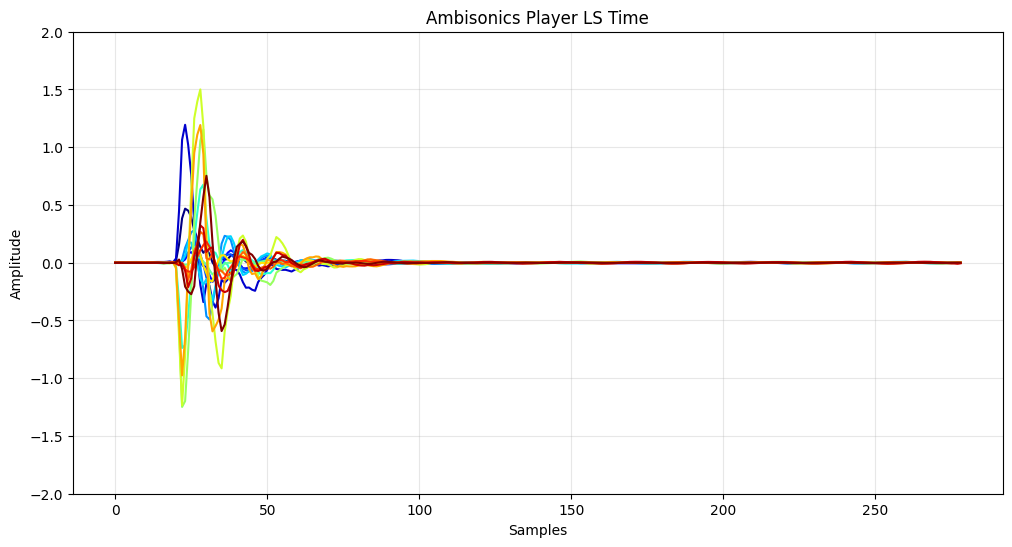

d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\.venv\Lib\site-packages\shroom\acoustics\spatial_signal.py:264: UserWarning: Signal is already in time domain.
  warnings.warn("Signal is already in time domain.")
d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


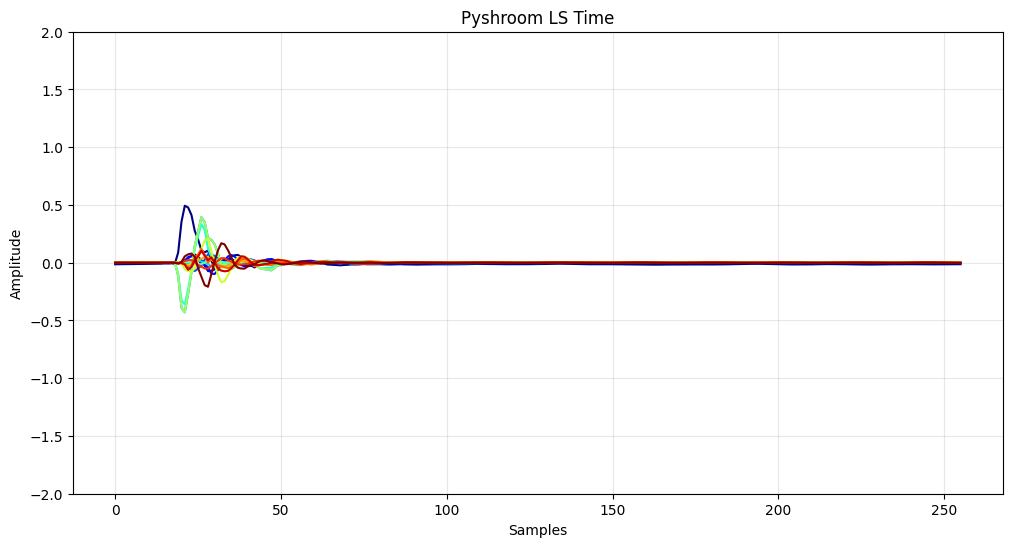

In [ ]:
samples = np.arange(0, my_own_ls.n_samples)
n_channels = 8

visualize_time(samples, my_own_ls[0], "Ambisonics Player LS Time")

# shroom_ls.toTime()
# # frequency axis
# samples = np.arange(0, shroom_ls.n_samples)

# visualize_time(samples, shroom_ls.data[0], "Pyshroom LS Time")



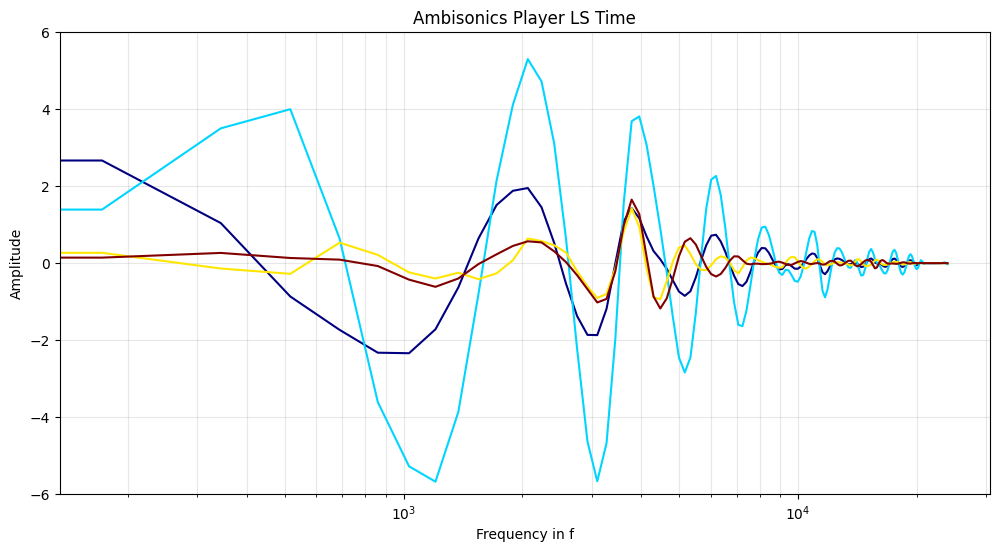

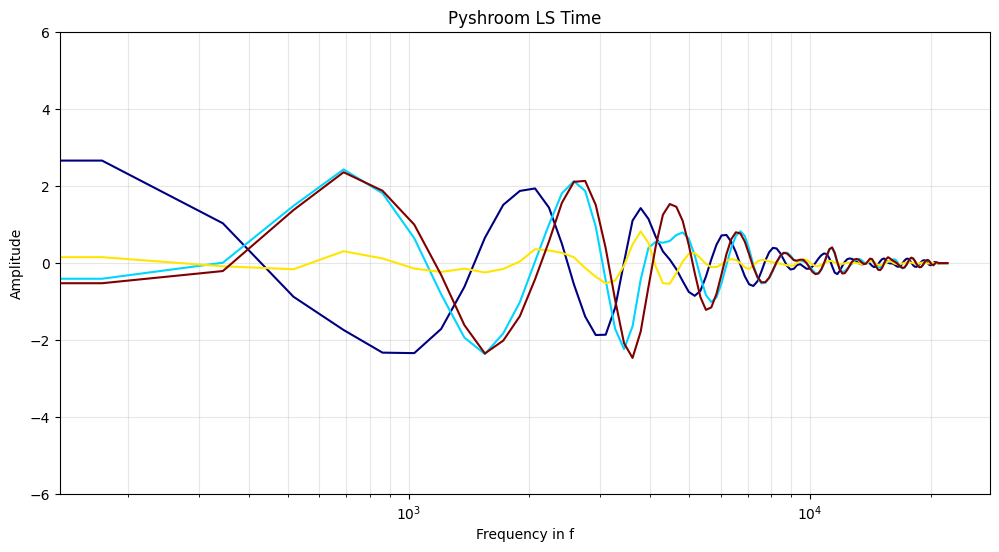

In [ ]:
freqs = my_own_ls.frequencies
n_channels = 4

visualize_freq(freqs, my_own_ls[0], "Ambisonics Player LS Time", n_channels)

# if shroom_ls.is_time:
#         shroom_ls.toFreq()

# fs = shroom_ls.fs
# duration = (1 / fs) * shroom_ls.data.shape[2]

# freq_axis = np.fft.fftfreq(n=int(duration * fs), d=1 / fs)
# nfft = len(freq_axis)
# pos_freq_axis = np.fft.rfftfreq(n=int(duration * fs), d=1 / fs)

# hrtf_sh = shroom_ls.data[..., : len(pos_freq_axis)]

# visualize_freq(pos_freq_axis, hrtf_sh[0], "Pyshroom LS Time", n_channels)



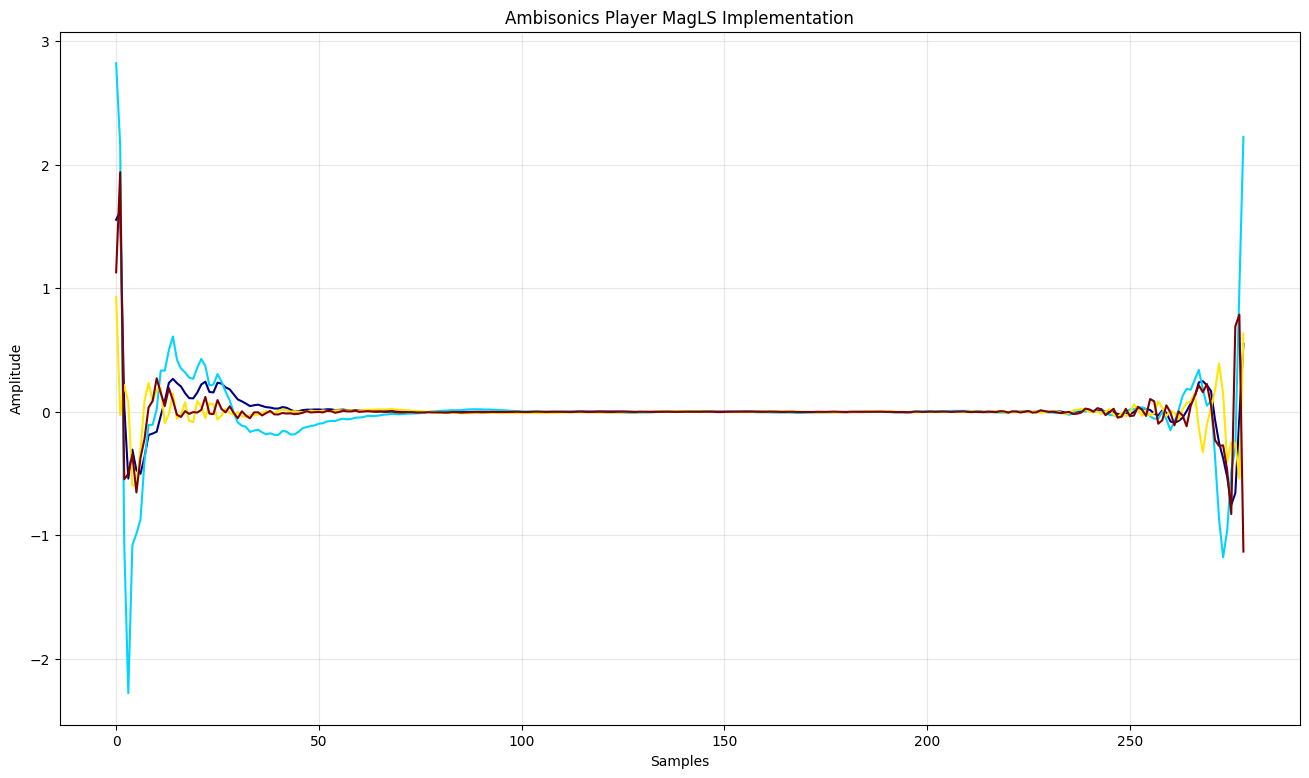

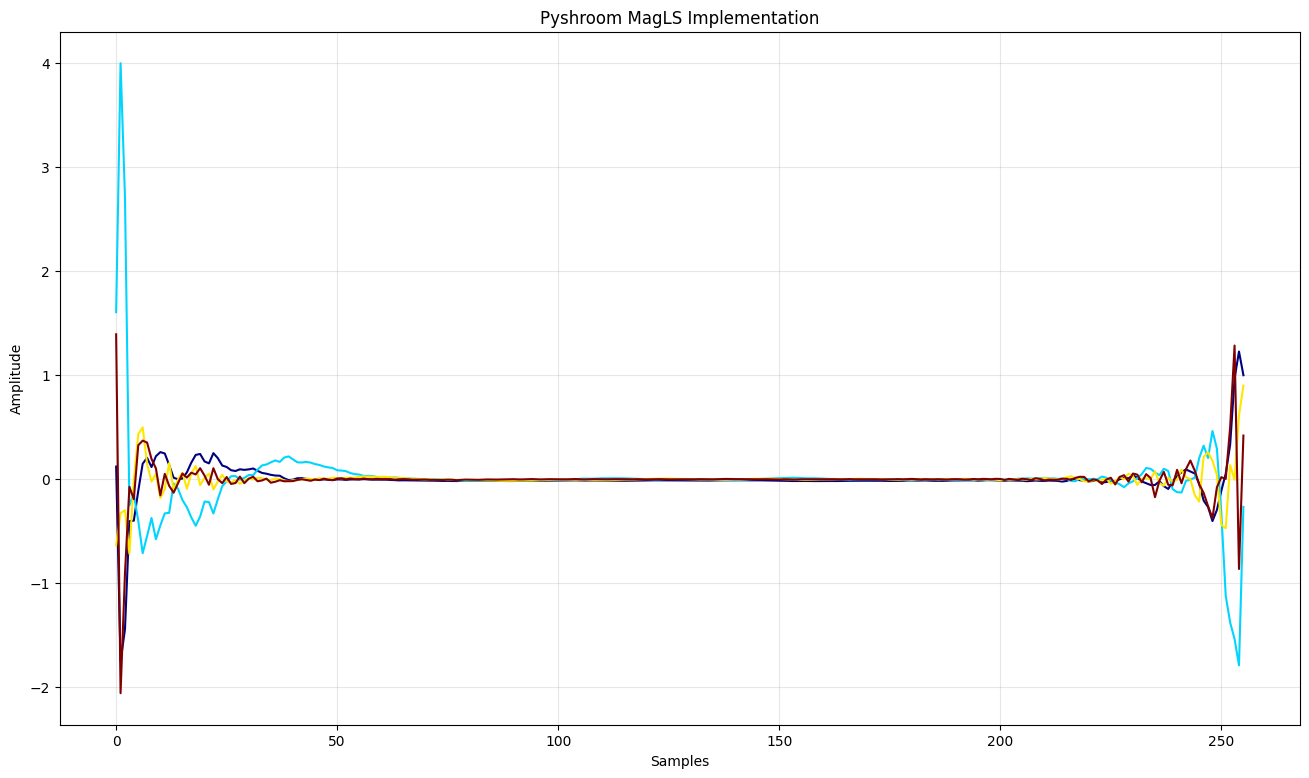

In [ ]:
# frequency axis
samples = np.arange(0, my_own_magls.n_samples)

visualize_time(samples, my_own_magls[0], "Ambisonics Player MagLS Implementation", n_channels=4)

# _, n_samples = shroom_ls.shape
# # frequency axis
# samples = np.arange(0, n_samples)

# visualize_time(samples, shroom_magls, "Pyshroom MagLS Implementation", 4)